In [3]:
# وارد کردن کتابخانه‌ها
import numpy as np
import keras
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, regularizers, constraints, models
from tensorflow.keras.initializers import HeNormal ,GlorotUniform ,VarianceScaling
from tensorflow.keras import initializers
from tensorflow.keras.utils import register_keras_serializable

import matplotlib.pyplot as plt
from tensorflow.keras.callbacks import Callback 
from keras.callbacks import ModelCheckpoint, EarlyStopping, LearningRateScheduler, TensorBoard,ReduceLROnPlateau
import datetime
import time
import tensorflow as tf
import os

import warnings

warnings.filterwarnings('ignore')

In [4]:
(X_train , Y_train),(X_test , Y_test) = keras.datasets.cifar10.load_data()

In [5]:
print("توزیع کلاس‌ها در Y_test:", np.bincount(Y_test.flatten()))

توزیع کلاس‌ها در Y_test: [1000 1000 1000 1000 1000 1000 1000 1000 1000 1000]


In [6]:
print("محدوده مقادیر X_test قبل از نرمال‌سازی:", X_test.min(), X_test.max())
print("محدوده مقادیر X_test قبل از نرمال‌سازی:", X_train.min(), X_train.max())

محدوده مقادیر X_test قبل از نرمال‌سازی: 0 255
محدوده مقادیر X_test قبل از نرمال‌سازی: 0 255


In [7]:
X_train.shape

(50000, 32, 32, 3)

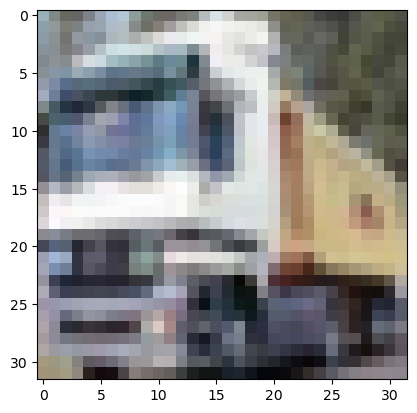

In [8]:
plt.imshow(X_train[1,:,:,:],cmap='gray')

In [9]:
X = np.concatenate((X_train ,X_test) , axis =0)
Y = np.concatenate((Y_train ,Y_test) , axis =0)
print("Dataset dimensions (X):", X.shape)
print("type (X):", X.dtype)
print("Dataset dimensions (Y):", Y.shape)
print("type (Y):", Y.dtype)

Dataset dimensions (X): (60000, 32, 32, 3)
type (X): uint8
Dataset dimensions (Y): (60000, 1)
type (Y): uint8


In [10]:
np.unique(Y)

array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9], dtype=uint8)

In [11]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.15)

In [12]:
# تقسیم داده‌های آموزشی به آموزش و اعتبارسنجی
X_train, X_val, Y_train, Y_val = train_test_split(X_train, Y_train, test_size=0.15)

In [13]:
X_train=X_train/255.0
X_val=X_val/255.0
X_test=X_test/255.0

In [14]:
Y_train = Y_train.reshape(-1)
Y_val = Y_val.reshape(-1)
Y_test = Y_test.reshape(-1)

##### می‌توانید از Mixed Precision Training برای افزایش سرعت آموزش و کاهش مصرف حافظه استفاده کنید:

In [15]:
from tensorflow.keras.mixed_precision import set_global_policy
set_global_policy('mixed_float16')

INFO:tensorflow:Mixed precision compatibility check (mixed_float16): OK
Your GPU will likely run quickly with dtype policy mixed_float16 as it has compute capability of at least 7.0. Your GPU: NVIDIA GeForce RTX 3070 Ti Laptop GPU, compute capability 8.6


## تنظیم Data Generator برای افزایش داده‌ها

In [16]:
def preprocess_image(image):
    # نرمال‌سازی تصویر به بازه [0, 1] و استانداردسازی (اختیاری، اینجا نمونه CIFAR-10)
    image = image.astype('float32')
    mean = [0.4914, 0.4822, 0.4465]
    std = [0.2470, 0.2435, 0.2616]
    image = (image - mean) / std
    return image

# تنظیم Data Generator برای افزایش داده‌ها
train_datagen = ImageDataGenerator(
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True,
    preprocessing_function=preprocess_image
)

val_datagen = ImageDataGenerator(preprocessing_function=preprocess_image)

# فرض بر این است که X_train, Y_train, X_val, Y_val قبلاً تعریف شده‌اند
# تنظیم flow
train_generator = train_datagen.flow(X_train, Y_train, batch_size=32)
val_generator = val_datagen.flow(X_val, Y_val, batch_size=32)

In [ ]:
# Data augmentation for improved generalization
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
    layers.RandomTranslation(height_factor=0.1, width_factor=0.1),
])
train_generator = data_augmentation(X_train)
val_generator = data_augmentation(X_val)

In [ ]:
# تابع پیش‌پردازش
def preprocess_image(image):
    """
    پیش‌پردازش تصویر برای نرمال‌سازی و استانداردسازی.
    تصویر به بازه [0, 1] نرمال‌سازی شده و با میانگین و انحراف معیار CIFAR-10 استاندارد می‌شود.
    
    Args:
        image: تصویر ورودی با نوع uint8 یا float32.
        
    Returns:
        تصویر پیش‌پردازش‌شده با نوع float32.
    """
    image = image.astype('float32')
    if image.max() > 1.0:  # اگر داده‌ها در بازه [0, 255] باشند
        image = image / 255.0
    mean = np.array([0.4914, 0.4822, 0.4465])
    std = np.array([0.2470, 0.2435, 0.2616])
    image = (image - mean) / std
    return image

# تنظیم ImageDataGenerator برای افزایش داده‌ها و پیش‌پردازش
train_datagen = ImageDataGenerator(
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True,
    zoom_range=0.2,
    shear_range=0.2,
    fill_mode='nearest',
    preprocessing_function=preprocess_image
)

val_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_image
)

def setup_data_generators(X_train, Y_train, X_val, Y_val, X_test=None, Y_test=None, batch_size=32):
    """
    تنظیم ژنراتورهای داده برای داده‌های آموزشی، اعتبارسنجی و تست.
    
    Args:
        X_train: آرایه داده‌های آموزشی (تصاویر).
        Y_train: آرایه برچسب‌های آموزشی.
        X_val: آرایه داده‌های اعتبارسنجی.
        Y_val: آرایه برچسب‌های اعتبارسنجی.
        X_test: آرایه داده‌های تست (اختیاری).
        Y_test: آرایه برچسب‌های تست (اختیاری).
        batch_size: اندازه دسته (پیش‌فرض: 32).
        
    Returns:
        train_generator, val_generator, test_generator (اگر X_test و Y_test داده شده باشند).
    """
    # بررسی شکل داده‌ها
    if len(X_train.shape) != 4:
        raise ValueError("X_train must have shape (N, H, W, C)")
    if len(X_val.shape) != 4:
        raise ValueError("X_val must have shape (N, H, W, C)")

    # تنظیم ژنراتور آموزشی
    train_generator = train_datagen.flow(
        X_train, Y_train,
        batch_size=batch_size,
        shuffle=True
    )
    
    # تنظیم ژنراتور اعتبارسنجی
    val_generator = val_datagen.flow(
        X_val, Y_val,
        batch_size=batch_size,
        shuffle=False
    )
    
    # تنظیم ژنراتور تست (اختیاری)
    test_generator = None
    if X_test is not None and Y_test is not None:
        if len(X_test.shape) != 4:
            raise ValueError("X_test must have shape (N, H, W, C)")
        test_generator = val_datagen.flow(
            X_test, Y_test,
            batch_size=batch_size,
            shuffle=False
        )
    
    return train_generator, val_generator, test_generator

In [ ]:
# تنظیم ژنراتورها
batch_size = 64
train_generator, val_generator, test_generator = setup_data_generators(
    X_train, Y_train, X_val, Y_val, X_test, Y_test, batch_size=batch_size
)

# تعریف مدل

In [ ]:

model_conv = keras.models.Sequential([
        keras.Input(shape=[32, 32, 3]),
    #data_augmentation,
    
    # First Conv Block with increased filters
    layers.Conv2D(
        filters=64, kernel_size=3, strides=1, activation=None,
        padding='same', data_format='channels_last',
        kernel_initializer=HeNormal(),
        kernel_regularizer=regularizers.l2(1e-4),  # L2 regularization
        kernel_constraint=constraints.max_norm(3.0)
    ),
    layers.BatchNormalization(),
    layers.Activation('relu'),  # ReLU often works better than ELU for CNNs
    layers.Dropout(0.15),
    
    # Second Conv Block with improved architecture
    layers.Conv2D(
        filters=125, kernel_size=3, strides=1, activation=None,
        padding='same', data_format='channels_last',
        kernel_initializer=HeNormal(),
        kernel_regularizer=regularizers.l2(1e-4),
        kernel_constraint=constraints.max_norm(3.0)
    ),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.Dropout(0.1),
    layers.MaxPooling2D(pool_size=2, strides=2, padding="same"),
    
    # Third Conv Block with increased capacity
    layers.Conv2D(
        filters=256, kernel_size=3, strides=1, activation=None,
        padding='same', data_format='channels_last',
        kernel_initializer=HeNormal(),
        kernel_regularizer=regularizers.l2(1e-4),
        kernel_constraint=constraints.max_norm(3.0)
    ),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.Dropout(0.15),
    layers.MaxPooling2D(pool_size=2, strides=2, padding="same"),
    
    # Fourth Conv Block (added for more capacity)
    layers.Conv2D(
        filters=560, kernel_size=3, strides=1, activation=None,
        padding='same', data_format='channels_last',
        kernel_initializer=HeNormal(),
        kernel_regularizer=regularizers.l2(1e-4),
        kernel_constraint=constraints.max_norm(3.0)
    ),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.Dropout(0.2),
    layers.MaxPooling2D(pool_size=2, strides=2, padding="same"),
    
    # Global pooling
    layers.GlobalAveragePooling2D(data_format='channels_last'),
    
    # First Dense layer
    layers.Dense(
        256, activation=None,
        kernel_initializer=HeNormal(),
        kernel_regularizer=regularizers.l2(1e-4),
        kernel_constraint=constraints.max_norm(3.0)
    ),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.Dropout(0.3),  # Increased dropout for better regularization
    
    # Second Dense layer
    layers.Dense(
        128, activation=None,
        kernel_initializer=HeNormal(),
        kernel_regularizer=regularizers.l2(1e-4),
        kernel_constraint=constraints.max_norm(3.0)
    ),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.Dropout(0.3),
    
    # Output layer
    layers.Dense(10, activation="softmax", kernel_initializer=GlorotUniform(),kernel_regularizer=regularizers.l2(1e-4))
])


## callback

In [ ]:
# بررسی و اصلاح مسیر logs/fit
if os.path.exists('logs/fit') and not os.path.isdir('logs/fit'):
    print("logs/fit یه فایل هست، نه دایرکتوری. حذفش می‌کنم...")
    os.remove('logs/fit')  # اگه فایل باشه، حذفش می‌کنه
os.makedirs('logs/fit', exist_ok=True)  # دایرکتوری رو دوباره می‌سازه

In [ ]:
# تعریف مسیر لاگ‌ها
log_dir = "logs/fit/" + datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
print(f"مسیر لاگ‌ها: {log_dir}")

# تعریف TensorBoard callback
tensorboard_callback = TensorBoard(log_dir=log_dir, histogram_freq=1, write_graph=True)

مسیر لاگ‌ها: logs/fit/20250411-231638


In [ ]:
# تعریف callbacks
conv_checkpoint_filepath = 'best_conv_model.keras'
conv_model_checkpoint_callback = ModelCheckpoint(
    filepath='best_conv_model.keras',
    monitor='val_loss',
    verbose=1,
    save_best_only=True,
    save_weights_only=False,
    mode='min'
)

In [ ]:
conv_early_stopping_callback = EarlyStopping(
    monitor='val_loss',
    patience=8,
    restore_best_weights=True,
    verbose=1
)

## ترکیب دو رش بالا که برای gpu سنگین است

# LearningRateScheduler 

## WarmUpCosineDecayScheduler

## ترکیب دو روش بالا

In [ ]:
# تعریف WarmUpCosineDecayReduceLROnPlateau
@register_keras_serializable()
class WarmUpCosineDecayReduceLROnPlateau(Callback):
    def __init__(self, base_lr, total_steps, warmup_steps, min_lr, monitor='val_loss', 
                 factor=0.5, patience=3, min_delta=0.0001, cooldown=0, verbose=1):
        super(WarmUpCosineDecayReduceLROnPlateau, self).__init__()
        self.base_lr = base_lr
        self.total_steps = total_steps
        self.warmup_steps = warmup_steps
        self.min_lr = min_lr
        self.monitor = monitor
        self.factor = factor
        self.patience = patience
        self.min_delta = min_delta
        self.cooldown = cooldown
        self.verbose = verbose
        self.wait = 0
        self.best = np.Inf if monitor == 'val_loss' else -np.Inf
        self.cooldown_counter = 0
        self.current_step = 0

    def on_train_begin(self, logs=None):
        self.model.optimizer.learning_rate.assign(self.base_lr)

    def on_batch_end(self, batch, logs=None):
        self.current_step += 1
        if self.current_step < self.total_steps:
            # رفتار WarmUpCosineDecayScheduler
            lr = self._get_cosine_lr(self.current_step)
            self.model.optimizer.learning_rate.assign(lr)

    def on_epoch_end(self, epoch, logs=None):
        if self.current_step >= self.total_steps:
            # رفتار ReduceLROnPlateau
            current_metric = logs.get(self.monitor)
            if current_metric is None:
                return

            if self._is_improvement(current_metric):
                self.best = current_metric
                self.wait = 0
            else:
                self.wait += 1
                if self.wait >= self.patience and self.cooldown_counter == 0:
                    current_lr = float(self.model.optimizer.learning_rate)
                    new_lr = max(current_lr * self.factor, self.min_lr)
                    if current_lr - new_lr > self.min_delta:
                        self.model.optimizer.learning_rate.assign(new_lr)
                        if self.verbose > 0:
                            print(f'\nEpoch {epoch+1}: ReduceLROnPlateau reducing learning rate to {new_lr:.6f}.')
                        self.cooldown_counter = self.cooldown
                        self.wait = 0

            if self.cooldown_counter > 0:
                self.cooldown_counter -= 1

    def _get_cosine_lr(self, step):
        if step < self.warmup_steps:
            lr = self.base_lr * step / self.warmup_steps
        else:
            progress = (step - self.warmup_steps) / (self.total_steps - self.warmup_steps)
            cosine_decay = 0.5 * (1 + tf.math.cos(tf.constant(np.pi) * progress))
            lr = self.min_lr + (self.base_lr - self.min_lr) * cosine_decay
        return lr

    def _is_improvement(self, current_metric):
        if self.monitor == 'val_loss':
            return current_metric < self.best - self.min_delta
        return current_metric > self.best + self.min_delta

    def get_config(self):
        return {
            'base_lr': self.base_lr,
            'total_steps': self.total_steps,
            'warmup_steps': self.warmup_steps,
            'min_lr': self.min_lr,
            'monitor': self.monitor,
            'factor': self.factor,
            'patience': self.patience,
            'min_delta': self.min_delta,
            'cooldown': self.cooldown,
            'verbose': self.verbose
        }

    @classmethod
    def from_config(cls, config):
        return cls(**config)



In [ ]:
# تنظیم پارامترها (فرض می‌کنیم train_generator و val_generator تعریف شده‌اند)
epochs = 30
steps_per_epoch = len(train_generator)  # باید train_generator تعریف شده باشد
total_steps = epochs * steps_per_epoch
warmup_steps = int(0.1 * total_steps)  # 10% warmup

# تعریف برنامه‌ریز ترکیبی
lr_scheduler = WarmUpCosineDecayReduceLROnPlateau(
    base_lr=1e-3,
    total_steps=total_steps,
    warmup_steps=warmup_steps,
    min_lr=1e-7,  
    monitor='val_loss',
    factor=0.4,  
    patience=3,
    min_delta=0.0001,
    cooldown=0,
    verbose=1
)



### تنظیم کاهش نرخ یادگیری با ReduceLROnPlateau

###  برنامه زمانی نرخ یادگیری OneCycle

In [ ]:
# برنامه زمانی نرخ یادگیری
initial_lr = 0.0001
max_lr = 0.003
# آموزش مدل
batch_size = 80

# برنامه زمانی نرخ یادگیری OneCycle
def one_cycle_lr(epoch, initial_lr, max_lr, epochs):
    if epoch < epochs // 5:  # 20% اول - گرم کردن
        return initial_lr + (max_lr - initial_lr) * (epoch / (epochs // 5))
    else:  # 80% باقیمانده - کاهش کسینوسی
        decay_epochs = epochs - (epochs // 5)
        decay_epoch = epoch - (epochs // 5)
        cosine_decay = 0.5 * (1 + math.cos(math.pi * decay_epoch / decay_epochs))
        return initial_lr + (max_lr - initial_lr) * cosine_decay
        
lr_scheduler_cyc = LearningRateScheduler(
    lambda epoch: one_cycle_lr(epoch, initial_lr, max_lr, epochs)
)

### ExponentialDecay

In [ ]:
# Compile with improved optimizer and learning rate schedule
initial_learning_rate = 0.001
lr_schedule_exp = keras.optimizers.schedules.ExponentialDecay(
    initial_learning_rate, decay_steps=10000, decay_rate=0.9, staircase=True
)

## برای مشاهده مسیر lr

In [ ]:
# تعریف LearningRateTracker
@register_keras_serializable()
class LearningRateTracker(Callback):
    def __init__(self, steps_per_epoch):
        super().__init__()
        self.steps_per_epoch = steps_per_epoch
        self.lr_values = []

    def on_epoch_begin(self, epoch, logs=None):
        """Print the current learning rate at the start of each epoch."""
        lr = float(self.model.optimizer.learning_rate)
        print(f"Epoch {epoch + 1} - Learning Rate: {lr:.6f}")
        self.lr_values.append(lr)

    def get_config(self):
        """Return configuration for serialization."""
        return {
            'steps_per_epoch': self.steps_per_epoch
        }

    @classmethod
    def from_config(cls, config):
        return cls(**config)

# تعریف lr_tracker
lr_tracker = LearningRateTracker(steps_per_epoch)

In [ ]:
# تعریف بهینه‌ساز با Clipping گرادیان‌ها
optimizer = tf.keras.optimizers.Adam(
    learning_rate=1e-3,  # نرخ یادگیری اولیه (توسط lr_scheduler مدیریت می‌شود)
    clipvalue=0.5  
    # GlobalNorm Clipping
)

# تعریف تابع loss
loss_conv = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False)

# کامپایل مدل
model_conv.compile(
    loss=loss_conv,
    optimizer=optimizer,
    metrics=["accuracy"]
)


In [ ]:
from tensorflow.keras.callbacks import ReduceLROnPlateau
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=5, min_lr=1e-6, verbose=1)

In [ ]:
# آموزش مدل
start = time.time()
history_conv = model_conv.fit(
    X_train, Y_train,
    epochs=epochs,
    validation_data=(X_val,Y_val),
    callbacks=[
        conv_model_checkpoint_callback,
        conv_early_stopping_callback,
        lr_tracker,
        lr_scheduler  # استفاده از lr_scheduler
    ],
    verbose=1
)

time_conv = time.time() - start
print(f"زمان آموزش: {time_conv} ثانیه")

Epoch 1 - Learning Rate: 0.001000
Epoch 1/30
1355/1355 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step - accuracy: 0.2711 - loss: 2.3651  
Epoch 1: val_loss improved from inf to 1.83893, saving model to best_conv_model.keras
1355/1355 ━━━━━━━━━━━━━━━━━━━━ 181s 131ms/step - accuracy: 0.2712 - loss: 2.3649 - val_accuracy: 0.4407 - val_loss: 1.8389
Epoch 2 - Learning Rate: 0.000666
Epoch 2/30
1355/1355 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step - accuracy: 0.5086 - loss: 1.6341  
Epoch 2: val_loss improved from 1.83893 to 1.64430, saving model to best_conv_model.keras
1355/1355 ━━━━━━━━━━━━━━━━━━━━ 175s 129ms/step - accuracy: 0.5086 - loss: 1.6340 - val_accuracy: 0.4898 - val_loss: 1.6443
Epoch 3 - Learning Rate: 0.000997
Epoch 3/30
1355/1355 ━━━━━━━━━━━━━━━━━━━━ 0s 117ms/step - accuracy: 0.6270 - loss: 1.3230  
Epoch 3: val_loss improved from 1.64430 to 1.49886, saving model to best_conv_model.keras
1355/1355 ━━━━━━━━━━━━━━━━━━━━ 166s 123ms/step - accuracy: 0.6270 - loss: 1.3230 - val_accuracy: 0.5725 - val_

In [ ]:
# استخراج optimizer از مدل بارگذاری‌شده
optimizer = best_conv_model.optimizer

# دریافت لرنینگ ریت
current_lr = optimizer.learning_rate.numpy()

# نمایش لرنینگ ریت تا 10 رقم اعشار
print("Learning Rate:", "{:.10f}".format(current_lr))


Learning Rate: 0.0000001000


زمان آموزش بهترین مدل فصل قبل بدون فریز: 37.97 ثانیه

In [ ]:
print(Y_test.shape)

(9000,)


In [ ]:
print(Y_test.shape)

(9000,)


In [ ]:
if X_test.max() > 1 or X_test.min() < 0:
    raise ValueError("ورودی باید از قبل پیش‌پردازش شده باشد.")

In [ ]:
test_loss, test_acc = model_conv.evaluate(X_test, Y_test)
print(f"Test accuracy: {test_acc:.4f}, Test loss: {test_loss:.4f}")

282/282 ━━━━━━━━━━━━━━━━━━━━ 9s 33ms/step - accuracy: 0.8563 - loss: 0.6563
Test accuracy: 0.8528, Test loss: 0.6719


In [ ]:
# بارگذاری مدل با custom_objects
best_conv_model = tf.keras.models.load_model(
    'best_conv_model.keras',
    custom_objects={
        'WarmUpCosineDecayReduceLROnPlateau': WarmUpCosineDecayReduceLROnPlateau,  # نام صحیح کلاس
        'LearningRateTracker': LearningRateTracker  # اضافه کردن LearningRateTracker
    }
)

In [ ]:
# بررسی مدل بارگذاری‌شده
best_conv_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 64)     │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 125)    │        72,125 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32, 32, 125)    │           500 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 32, 32, 125)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32, 32, 125)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 125)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 256)    │       288,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 16, 16, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 16, 16, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 16, 16, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 8, 8, 560)      │     1,290,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 8, 8, 560)      │         2,240 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 8, 8, 560)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 8, 8, 560)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 560)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 560)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       143,616 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │             

 Total params: 5,503,439 (20.99 MB)

 Trainable params: 1,833,553 (6.99 MB)

 Non-trainable params: 2,778 (10.85 KB)

 Optimizer params: 3,667,108 (13.99 MB)

In [ ]:
# تابع پیش‌بینی Monte Carlo Dropout
def predict_mc(model, x, T=100):
    """
    انجام پیش‌بینی با Monte Carlo Dropout.
    x باید آرایه‌ای با شکل (N, H, W, C) باشد و از قبل پیش‌پردازش شده باشد.
    
    Args:
        model: مدل Keras با لایه‌های Dropout.
        x: داده‌های ورودی (N, H, W, C).
        T: تعداد پیش‌بینی‌ها (پیش‌فرض: 100).
    
    Returns:
        آرایه پیش‌بینی‌ها با شکل (T, N, num_classes).
    """
    preds = np.array([model(x, training=True).numpy() for _ in range(T)])
    return preds  # شکل (T, N, num_classes)

# اطمینان از پیش‌پردازش داده‌ها
# فرض می‌کنیم X_test قبلاً تعریف شده است
if X_test.max() > 1:  # اگر داده‌ها نرمال‌سازی نشده باشند
    X_test = preprocess_image(X_test)

In [ ]:
# پیش‌بینی برای یک نمونه (بخش اول)
preds_mc = predict_mc(best_conv_model, X_test[0:1], T=100)  # شکل (100, 1, 10)
mean_pred = preds_mc.mean(axis=0)  # شکل (1, 10)
std_pred = preds_mc.std(axis=0)    # شکل (1, 10)
print(f"Prediction for first sample: {mean_pred}")
print(f"Uncertainty for first sample: {std_pred}")

Prediction for first sample: [[0.11506546 0.0818435  0.10972661 0.13137801 0.12587236 0.10165749
  0.0916592  0.07892986 0.08630248 0.07756507]]
Uncertainty for first sample: [[0.0165209  0.01341334 0.01201452 0.01242788 0.01196988 0.01301835
  0.01275814 0.01297255 0.01135128 0.01335249]]


In [ ]:
# پیش‌بینی برای 50 نمونه به‌صورت یکجا (بخش دوم)
preds_mc = predict_mc(best_conv_model, X_test[:50], T=100)  # شکل (100, 50, 10)
mean_preds = preds_mc.mean(axis=0)  # شکل (50, 10)
std_preds = preds_mc.std(axis=0)    # شکل (50, 10)

In [ ]:
# فرض می‌کنیم mean_preds و std_preds از قبل محاسبه شده‌اند
# mean_preds: شکل (50, 10)
# std_preds: شکل (50, 10)
# Y_test: برچسب‌های واقعی با شکل (9000,)

results = []
for i in range(50):
    mean = mean_preds[i]  # (10,)
    std = std_preds[i]    # (10,)
    predicted_class = int(np.argmax(mean))
    confidence = float(np.max(mean))
    uncertainty = float(np.max(std))
    
    # محاسبه درصد خطا (عدم قطعیت نسبی)
    error_percentage = (uncertainty / confidence) * 100 if confidence != 0 else float('inf')
    
    # استخراج برچسب واقعی
    true_class = int(Y_test[i])
    
    results.append({
        "index": i,
        "predicted_class": predicted_class,
        "true_class": true_class,
        "confidence": confidence,
        "uncertainty": uncertainty,
        "error_percentage": error_percentage
    })

# نمایش چند نتیجه
for result in results[:5]:
    print(result)

{'index': 0, 'predicted_class': 6, 'true_class': 6, 'confidence': 0.7910452485084534, 'uncertainty': 0.23028990626335144, 'error_percentage': 29.11210284083901}
{'index': 1, 'predicted_class': 3, 'true_class': 5, 'confidence': 0.5139234662055969, 'uncertainty': 0.2602827548980713, 'error_percentage': 50.646209409310025}
{'index': 2, 'predicted_class': 5, 'true_class': 5, 'confidence': 0.8685174584388733, 'uncertainty': 0.1741005778312683, 'error_percentage': 20.04571999556663}
{'index': 3, 'predicted_class': 4, 'true_class': 4, 'confidence': 0.9846945405006409, 'uncertainty': 0.02884652465581894, 'error_percentage': 2.9294896507857873}
{'index': 4, 'predicted_class': 4, 'true_class': 4, 'confidence': 0.9993828535079956, 'uncertainty': 0.0009355514775961637, 'error_percentage': 0.09361292064519885}


In [ ]:
# بازیابی مدل از checkpoint (در صورت نیاز)
checkpoint = tf.train.Checkpoint(model=model_conv)
checkpoint_dir = 'checkpoints/'
latest_checkpoint = tf.train.latest_checkpoint(checkpoint_dir)

if latest_checkpoint:
    status = checkpoint.restore(latest_checkpoint)
    status.expect_partial()
    print(f"مدل از {latest_checkpoint} بازیابی شد.")
else:
    print("هیچ چک‌پوینتی پیدا نشد.")

هیچ چک‌پوینتی پیدا نشد.


✅ 6. ذخیره نتایج پیش‌بینی با عدم قطعیت (در صورت نیاز)
مثلاً می‌خوای 100 تا تصویر اول تست رو با پیش‌بینی و عدم قطعیت ذخیره کنی:

Sample 0: Class=6, Confidence=0.7910, Uncertainty=0.2303
Sample 1: Class=3, Confidence=0.5139, Uncertainty=0.2603
Sample 2: Class=5, Confidence=0.8685, Uncertainty=0.1741
Sample 3: Class=4, Confidence=0.9847, Uncertainty=0.0288
Sample 4: Class=4, Confidence=0.9994, Uncertainty=0.0009


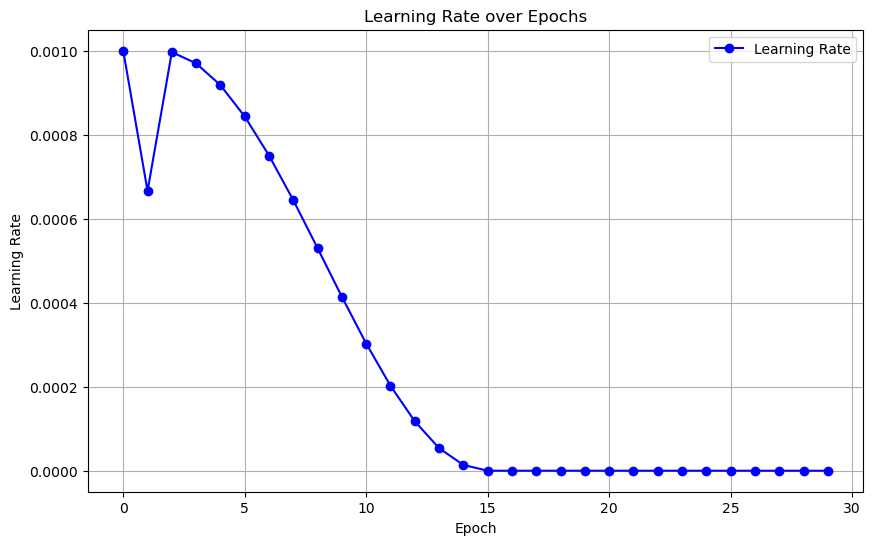

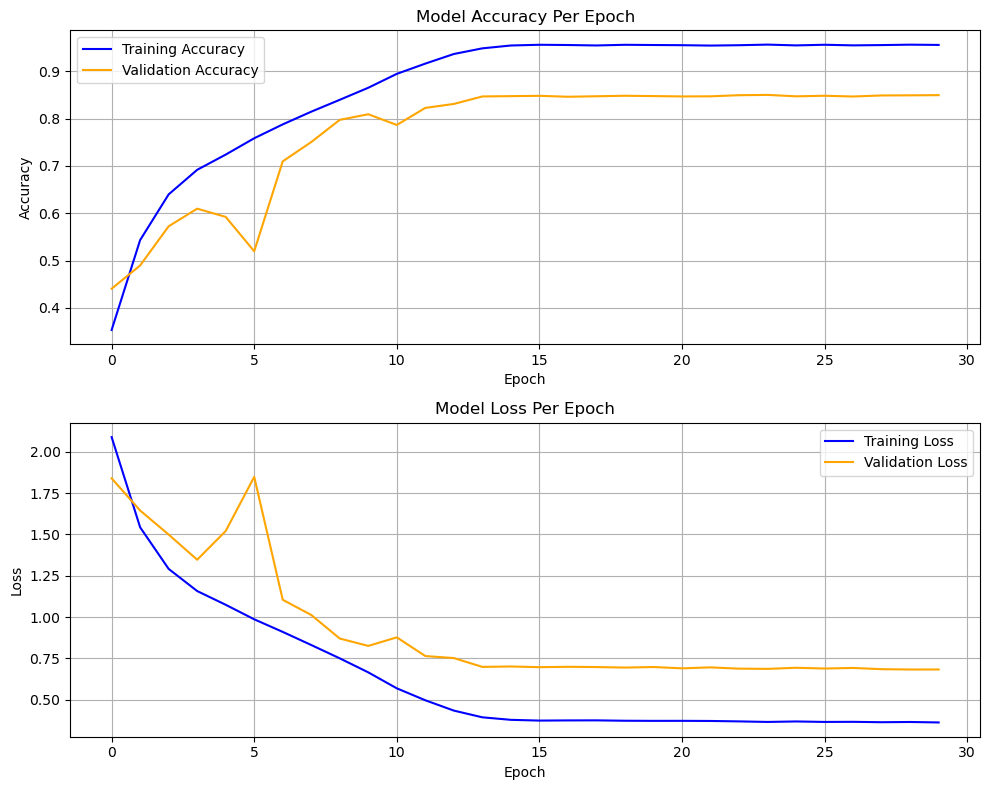

In [ ]:

# نمایش چند نتیجه از پیش‌بینی‌ها
for result in results[:5]:
    print(f"Sample {result['index']}: Class={result['predicted_class']}, Confidence={result['confidence']:.4f}, Uncertainty={result['uncertainty']:.4f}")

# رسم نمودار Learning Rate از lr_tracker
plt.figure(figsize=(10, 6))
plt.plot(lr_tracker.lr_values, marker='o', linestyle='-', color='b', label='Learning Rate')
plt.title("Learning Rate over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Learning Rate")
plt.grid(True)
plt.legend()
plt.show()

# رسم نمودارهای دقت و خطا
plt.figure(figsize=(10, 8))
plt.subplot(2, 1, 1)
plt.plot(history_conv.history['accuracy'], label='Training Accuracy', color='blue')
plt.plot(history_conv.history['val_accuracy'], label='Validation Accuracy', color='orange')
plt.legend()
plt.title('Model Accuracy Per Epoch')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.grid(True)

plt.subplot(2, 1, 2)
plt.plot(history_conv.history['loss'], label='Training Loss', color='blue')
plt.plot(history_conv.history['val_loss'], label='Validation Loss', color='orange')
plt.legend()
plt.title('Model Loss Per Epoch')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True)

plt.tight_layout()
plt.show()

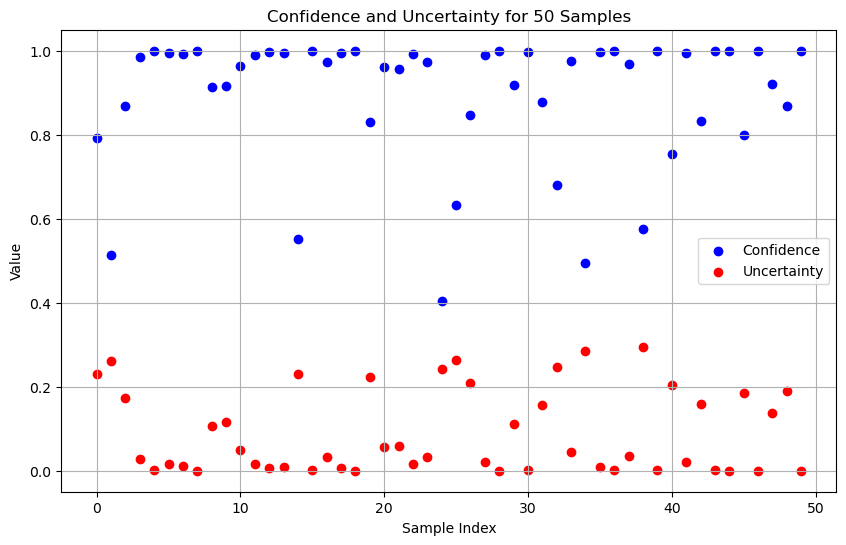

In [ ]:
confidences = [result["confidence"] for result in results]
uncertainties = [result["uncertainty"] for result in results]
plt.figure(figsize=(10, 6))
plt.scatter(range(len(confidences)), confidences, label="Confidence", color="blue")
plt.scatter(range(len(uncertainties)), uncertainties, label="Uncertainty", color="red")
plt.title("Confidence and Uncertainty for 50 Samples")
plt.xlabel("Sample Index")
plt.ylabel("Value")
plt.legend()
plt.grid(True)
plt.show()

282/282 ━━━━━━━━━━━━━━━━━━━━ 9s 30ms/step


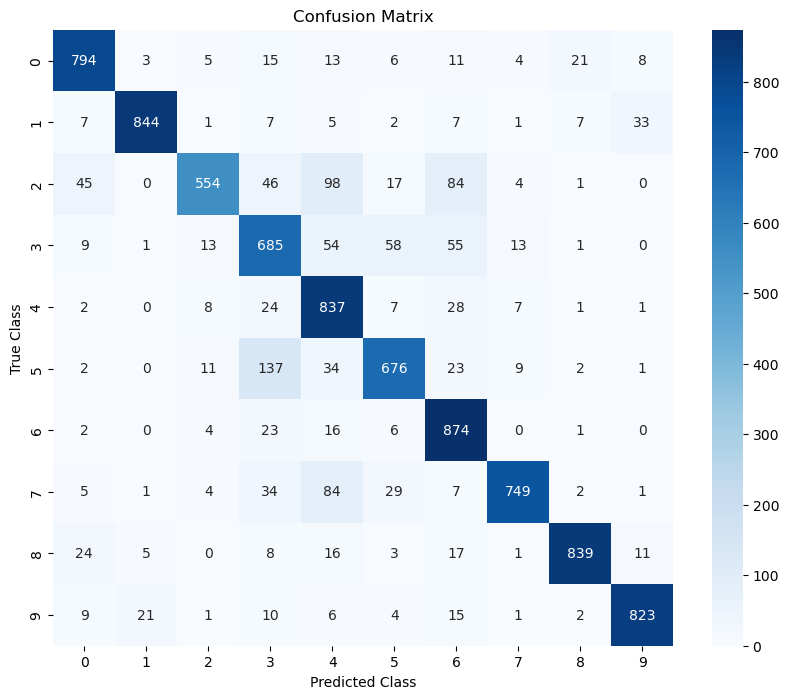

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

# پیش‌بینی‌ها رو از مدل می‌گیریم
Y_pred = model_conv.predict(X_test)
Y_pred_classes = np.argmax(Y_pred, axis=1)  # کلاس با بیشترین احتمال

# ماتریس سردرگمی رو محاسبه می‌کنیم (فرض می‌کنیم Y_test برچسب‌های واقعی هست)
cm = confusion_matrix(Y_test, Y_pred_classes)

# نمایش ماتریس با یه گرافیک قشنگ
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=range(10), yticklabels=range(10))
plt.title("Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("True Class")
plt.show()

In [ ]:
from sklearn.utils.class_weight import compute_class_weight
class_weights = compute_class_weight('balanced', classes=np.unique(Y_train), y=Y_train.flatten())
class_weight_dict = dict(enumerate(class_weights))

240/240 ━━━━━━━━━━━━━━━━━━━━ 7s 29ms/step
دمای بهینه: 0.20

282/282 ━━━━━━━━━━━━━━━━━━━━ 8s 29ms/step


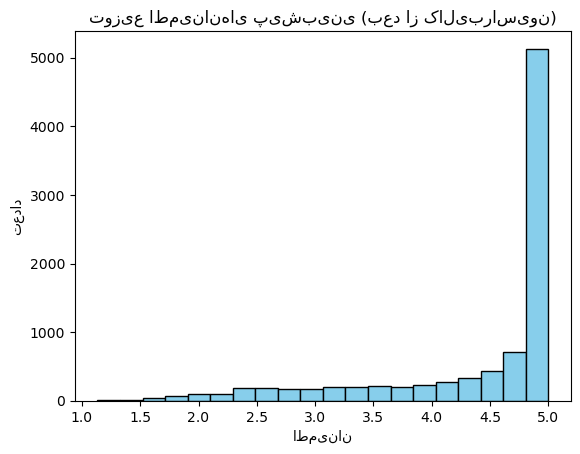

In [ ]:
from sklearn.metrics import log_loss

# تابع برای پیدا کردن دمای بهینه
def find_optimal_temperature(model, X_val, Y_val, temperature_range=np.arange(0.1, 5.0, 0.1)):
    best_temp = 1.0
    best_loss = float('inf')
    logits = model.predict(X_val)
    for temp in temperature_range:
        scaled_logits = logits / temp
        probs = tf.nn.softmax(scaled_logits).numpy()
        # چون Y_val sparse هست، از sparse_categorical_crossentropy استفاده می‌کنیم
        loss = tf.keras.losses.sparse_categorical_crossentropy(Y_val, probs, from_logits=False).numpy().mean()
        if loss < best_loss:
            best_loss = loss
            best_temp = temp
    return best_temp

# پیدا کردن دمای بهینه
optimal_temp = find_optimal_temperature(model_conv, X_val, Y_val)
print(f"دمای بهینه: {optimal_temp:.2f}")

# تعریف لایه Temperature Scaling
class TemperatureScaling(tf.keras.layers.Layer):
    def __init__(self, temperature=1.0, **kwargs):
        super(TemperatureScaling, self).__init__(**kwargs)
        self.temperature = temperature
    def call(self, logits):
        return logits / self.temperature

# اضافه کردن لایه به مدل
calibrated_model = tf.keras.Sequential([model_conv, TemperatureScaling(temperature=optimal_temp)])

# محاسبه کالیبراسیون برای مدل اصلی (قبل از کالیبراسیون)
Y_pred = model_conv.predict(X_test)
Y_pred_classes = np.argmax(Y_pred, axis=1)
prob_true, prob_pred = calibration_curve(Y_test.flatten() == Y_pred_classes, np.max(Y_pred, axis=1), n_bins=10)

# رسم هیستوگرام جدید
plt.hist(confidences_calibrated, bins=20, color='skyblue', edgecolor='black')
plt.title("Distribution of Prediction Confidences")
plt.xlabel("Confidence")
plt.ylabel("Frequency")
plt.show()

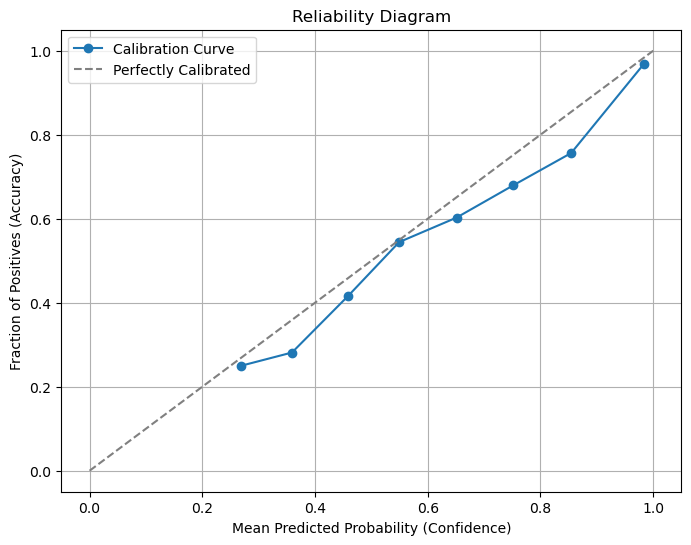

In [ ]:
from sklearn.calibration import calibration_curve
# رسم Reliability Diagram
plt.figure(figsize=(8, 6))
plt.plot(prob_pred, prob_true, marker='o', label='Calibration Curve')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Perfectly Calibrated')
plt.xlabel('Mean Predicted Probability (Confidence)')
plt.ylabel('Fraction of Positives (Accuracy)')
plt.title('Reliability Diagram')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
calibrated_model.compile(
    optimizer='adam',  # همون بهینه‌ساز مدل اصلی
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
    metrics=['accuracy']
)

In [ ]:
# ارزیابی نهایی
test_loss, test_acc = calibrated_model.evaluate(X_test, Y_test)
print(f"دقت تست: {test_acc:.4f}, خطای تست: {test_loss:.4f}")

282/282 ━━━━━━━━━━━━━━━━━━━━ 8s 27ms/step - accuracy: 0.8563 - loss: 0.6807
دقت تست: 0.8528, خطای تست: 0.6926


# exp , cycle

In [ ]:
# آموزش مدل
start = time.time()
history_conv_cyc = model_conv.fit(
    X_train, Y_train,
    epochs=epochs,
    validation_data=(X_val,Y_val),
    callbacks=[
        conv_model_checkpoint_callback,
        conv_early_stopping_callback,
        lr_tracker,
        lr_scheduler_cyc  # استفاده از lr_scheduler
    ],
    verbose=1
)

time_conv_cyc = time.time() - start
print(f"زمان آموزش: {time_conv} ثانیه")

In [ ]:
# آموزش مدل
start = time.time()
history_conv_exp = model_conv.fit(
    X_train, Y_train,
    epochs=epochs,
    validation_data=(X_val,Y_val),
    callbacks=[
        conv_model_checkpoint_callback,
        conv_early_stopping_callback,
        lr_tracker,
        lr_schedule_exp  # استفاده از lr_scheduler
    ],
    verbose=1
)

time_conv_exp = time.time() - start
print(f"زمان آموزش: {time_conv} ثانیه")

# frozen and unfrozen resnet

In [ ]:
from tensorflow.keras.applications import ResNet50
# تابع برای ساخت مدل
def build_model_resnet(freeze_all=True, trainable_block=None):
    # بارگذاری ResNet50 بدون لایه‌های بالایی
    base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(32, 32, 3))
    
    # فریز کردن لایه‌ها
    if freeze_all:
        for layer in base_model.layers:
            layer.trainable = False
    else:
        # فریز کردن همه لایه‌ها به جز بلوک مشخص‌شده
        for layer in base_model.layers:
            layer.trainable = False
        # باز کردن بلوک آخر (conv5_block3) برای آموزش
        for layer in base_model.layers:
            if layer.name.startswith(trainable_block):
                layer.trainable = True
    
    # اضافه کردن لایه‌های خروجی
    model = models.Sequential([
        base_model,
        layers.GlobalAveragePooling2D(),
        layers.Dense(256, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(10, activation='softmax')
    ])
    
    # کامپایل مدل
    model.compile(
        optimizer='adam',
        loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
        metrics=['accuracy']
    )
    return model

# حالت 1: فریز کامل
model_frozen_resnet = build_model_resnet(freeze_all=True)
history_frozen_resnet = model_frozen_resnet.fit(
    train_generator,
    epochs=50,
    validation_data=val_generator,
    verbose=1
)

# حالت 2: فریز جزئی (آخرین بلوک قابل آموزش)
model_partial_resnet = build_model_resnet(freeze_all=False, trainable_block='conv5_block3')
history_partial_resnet = model_partial_resnet.fit(
    train_generator,
    epochs=50,
    validation_data=val_generator,
    verbose=1
)

# رسم نمودارها
plt.figure(figsize=(12, 5))

# نمودار دقت
plt.subplot(1, 2, 1)
plt.plot(history_frozen_resnet.history['val_accuracy'], label='فریز کامل - دقت')
plt.plot(history_partial_resnet.history['val_accuracy'], label='فریز جزئی - دقت')
plt.title('دقت تست در طول ایپاک‌ها')
plt.xlabel('ایپاک')
plt.ylabel('دقت')
plt.legend()
plt.grid(True)

# نمودار خطا
plt.subplot(1, 2, 2)
plt.plot(history_frozen_resnet.history['val_loss'], label='فریز کامل - خطا')
plt.plot(history_partial_resnet.history['val_loss'], label='فریز جزئی - خطا')
plt.title('خطای تست در طول ایپاک‌ها')
plt.xlabel('ایپاک')
plt.ylabel('خطا')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

# ارزیابی نهایی
test_loss_frozen_resnet, test_acc_frozen_resnet = model_frozen_resnet.evaluate(X_test, Y_test)
test_loss_partial_resnet, test_acc_partial_resnet = model_partial_resnet.evaluate(X_test, Y_test)

print(f"فریز کامل - دقت تست: {test_acc_frozen_resnet:.4f}, خطای تست: {test_loss_frozen_resnet:.4f}")
print(f"فریز جزئی - دقت تست: {test_acc_partial_resnet:.4f}, خطای تست: {test_loss_partial_resnet:.4f}")

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 17s 0us/step
Epoch 1/50
678/678 ━━━━━━━━━━━━━━━━━━━━ 53s 70ms/step - accuracy: 0.2146 - loss: 2.1908 - val_accuracy: 0.3452 - val_loss: 1.8494
Epoch 2/50
140/678 ━━━━━━━━━━━━━━━━━━━━ 33s 61ms/step - accuracy: 0.2593 - loss: 2.0098

KeyboardInterrupt: 